In [1]:
import numpy as np
import zipfile

zip_path = r"C:\修論研究\VWT_historical_data\VWT_primary&derived_crops.zip"
filename = "VWT_item15_1986.txt"

with zipfile.ZipFile(zip_path, "r") as z:
    # zipの中にサブフォルダがあるかもしれないので endswith で探す
    member = [m for m in z.namelist() if m.endswith(filename)][0]
    with z.open(member) as f:
        VWTmat = np.loadtxt(f)

print(VWTmat.shape, VWTmat.min(), VWTmat.max())

(255, 255) 0.0 8493499900.0


# VWT matをいろんな年、作物に対応できるようにする

In [2]:
VWT = {}  # (year, crop) -> np.ndarray
import numpy as np
import zipfile

def load_vwt_matrix(zip_path, year, crop):
    filename = f"VWT_item{crop}_{year}.txt"
    with zipfile.ZipFile(zip_path, "r") as z:
        member = [m for m in z.namelist() if m.endswith(filename)][0]
        with z.open(member) as f:
            mat = np.loadtxt(f)
    return mat
zip_path = r"C:\修論研究\VWT_historical_data\VWT_primary&derived_crops.zip"

years = range(1986, 2017)
crops = [15, 30]  # 例

VWT = {}

for year in years:
    for crop in crops:
        VWT[(year, crop)] = load_vwt_matrix(zip_path, year, crop)
        
        

In [3]:
VWT[(1987, 15)].shape

(255, 255)

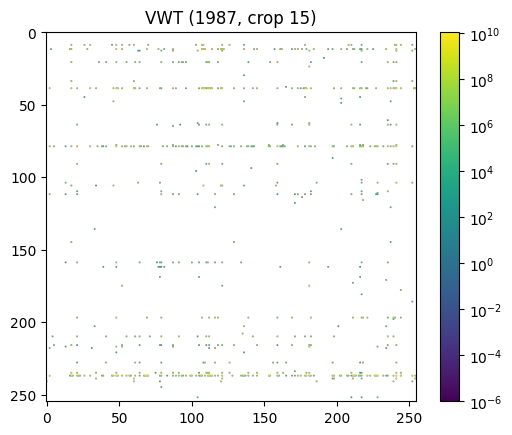

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.imshow(
    VWT[(1987, 15)],
    norm=LogNorm(vmin=1e-6)  # 0対策（重要）
)
plt.colorbar()
plt.title("VWT (1987, crop 15)")
plt.show()

In [5]:
# npyにして保存しておく（年、作物ごとに）
import os
output_dir = r"C:\修論研究\VWT_historical_data\VWT_npy"
os.makedirs(output_dir, exist_ok=True)
for (year, crop), mat in VWT.items():
    output_path = os.path.join(output_dir, f"VWT_{crop}_{year}.npy")
    np.save(output_path, mat)
# 読み込み例
# loaded_mat = np.load(output_path)



In [6]:
'''
import sys
!{sys.executable} -m pip install openpyxl
import sys
!{sys.executable} -m pip install geopandas

import sys
!{sys.executable} -m pip install geodatasets
'''

'\nimport sys\n!{sys.executable} -m pip install openpyxl\nimport sys\n!{sys.executable} -m pip install geopandas\n\nimport sys\n!{sys.executable} -m pip install geodatasets\n'

# 国名と対応させる

In [7]:
countrycode_file_path= r"C:\修論研究\VWT_historical_data\country_list.xlsx"
import pandas as pd
countrycode_df = pd.read_excel(countrycode_file_path)
countrycode_df.head()


,Country name,FAO code,Position,Reporting,Discontinuities,ISO3
0,Afghanistan,2,1,1,NaN,AFG
1,Albania,3,2,1,NaN,ALB
2,Algeria,4,3,1,NaN,DZA
3,American Samoa,5,4,0,NaN,ASM
4,Andorra,6,5,0,NaN,AND


In [8]:
# [0,0]が第１国目の名前に対応
print(countrycode_df.iloc[0,0])
print(countrycode_df.iloc[1,0])
print(countrycode_df.iloc[0,1])
print(countrycode_df.shape)


Afghanistan
Albania
2
(255, 6)


In [9]:
#ある国が何番目の国か　例、アフガニスタンは１番目の国（行列pythonのインデックスは0から始まるので、0番目の国）
country_name = "Albania"
country_index = countrycode_df[countrycode_df.iloc[:, 0] == country_name].index[0]
print(country_index)


1


# 10か国に関して分析してみる　輸入量、輸出量、差し引き、輸入先ネットワーク図、輸出先ネットワーク図、差し引きネットワーク図を可視化

In [10]:
ten_countries = [
    "Afghanistan",
    "Thailand",
    "ChinaMainland",
    "India",
    "United States of America",
    "France",
    "South Africa",
    "Brazil",
    "KoreaRepublic of",
    "Japan"
]

# 文字列の前後空白を除去して比較
name_col = countrycode_df.iloc[:, 0].astype(str).str.strip()

missing = [name for name in ten_countries if not (name_col == name).any()]
print("一致しなかった国:", missing)

一致しなかった国: []


In [11]:
ten_countries_index = [
    int(countrycode_df[countrycode_df.iloc[:, 0] == name].index[0])
    for name in ten_countries
]

print(ten_countries_index)

[0, 221, 48, 106, 237, 79, 208, 30, 121, 114]


# まずは行で10か国とって、各国の仮想水輸出を見てみる

In [ ]:
# 例えば、1987年の作物15の行列から、10か国のデータを抜き取る
VWT[(year, crop)]=np.load(r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy".format(crop=crop, year=year))
year = 1987
crop = 30
VWTmat = VWT[(year, crop)]
ten_countries_data = VWTmat[ten_countries_index, :]
print(ten_countries_data.max(), ten_countries_data.min())


2650661200.0 0.0


In [ ]:
#日本がどこにどれだけコメの仮想水を輸出しているか
year = 2015
crop = 30
VWTmat = VWT[(year, crop)]
japan_index = countrycode_df[countrycode_df.iloc[:, 0] == "Japan"].index[0]
japan_exports = VWTmat[japan_index, :]
print(japan_exports)


In [14]:
import geodatasets
print([d for d in geodatasets.data if "natural" in d.lower() and ("admin" in d.lower() or "country" in d.lower())])

[]


In [15]:
import geopandas as gpd

world = gpd.read_file(
    r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"
)

print(world.columns)

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='object', length=169)


In [16]:
world["SOV_A3"] = world["SOV_A3"].astype(str)
world = world[world["SOV_A3"] != "-99"].copy()

In [18]:
dest = country_list.copy()

dest = dest[["ISO3"]].rename(columns={"ISO3": "iso3"})
dest["export"] = japan_exports

NameError: name 'country_list' is not defined

In [17]:
m = world.merge(
    dest[["iso3", "export"]],
    left_on="SOV_A3",
    right_on="iso3",
    how="left"
)

NameError: name 'dest' is not defined

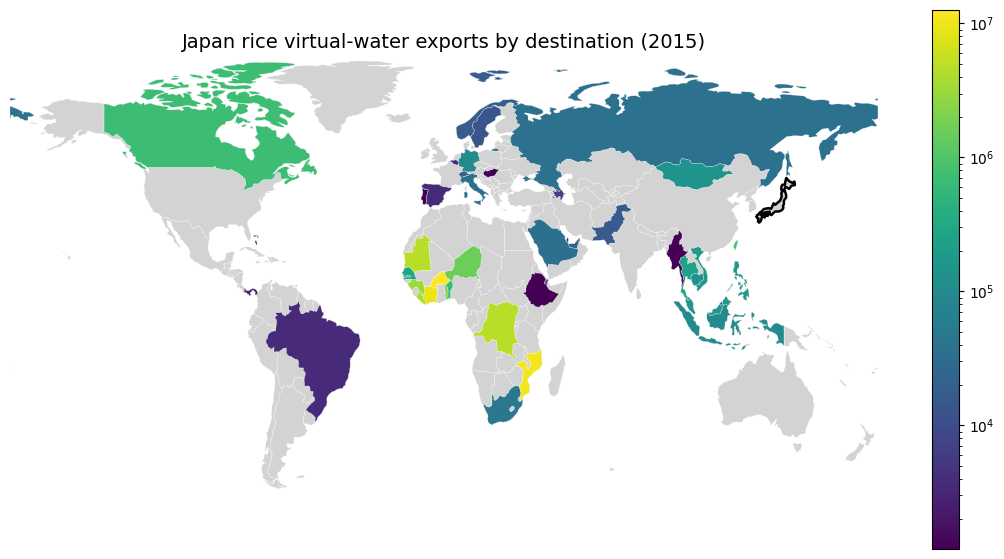

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(1, 1, figsize=(14, 7))
ax.set_axis_off()
ax.set_title("Japan rice virtual-water exports by destination (2015)", fontsize=14)

# ベース（輸出なし・NaN）
m.plot(
    ax=ax,
    color="lightgrey",
    linewidth=0.2,
    edgecolor="white"
)

# 正の輸出だけ塗る
pos = m["export"].fillna(0) > 0
if pos.any():
    m.loc[pos].plot(
        ax=ax,
        column="export",
        norm=LogNorm(
            vmin=m.loc[pos, "export"].min(),
            vmax=m.loc[pos, "export"].max()
        ),
        linewidth=0.2,
        edgecolor="white",
        legend=True,
    )

# 日本を強調
jpn = m[m["SOV_A3"] == "JPN"]
if len(jpn) > 0:
    jpn.boundary.plot(ax=ax, linewidth=1.8, color="black")

ax.set_xlim(-180, 180)
ax.set_ylim(-60, 85)

plt.show()